In [ ]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import heapq

torch.manual_seed(42)
np.random.seed(42)

In [ ]:
seq_len = 200
d_model = 64

# Fake tokens → random embeddings
X = torch.randn(seq_len, d_model)

# Projection matrices
Wq = torch.randn(d_model, d_model)
Wk = torch.randn(d_model, d_model)
Wv = torch.randn(d_model, d_model)

Q = X @ Wq
K = X @ Wk
V = X @ Wv

In [ ]:
def attention(Q, K, V):
    scores = Q @ K.T
    weights = F.softmax(scores, dim=-1)
    output = weights @ V
    return output, weights

In [ ]:
out_full, weights_full = attention(Q, K, V)

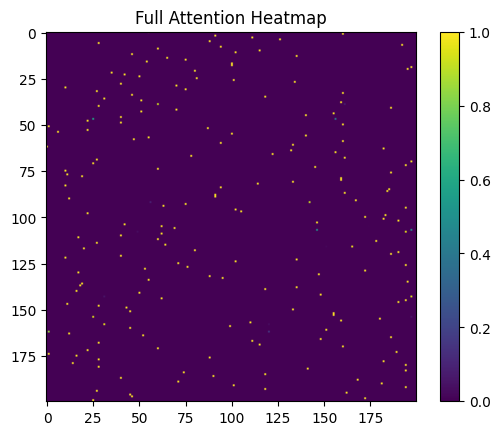

In [ ]:
plt.imshow(weights_full.detach().numpy())
plt.title("Full Attention Heatmap")
plt.colorbar()
plt.show()

In [173]:
def attention_topk_compaction(K, V, weights, effective_budget):
    importance = weights.sum(dim=0)
    indices = torch.argsort(importance)[-effective_budget:]
    return K[indices], V[indices]

In [148]:
ratio = 0.5
k_budget = int(seq_len * ratio)
bin_size = 10
k_rank = 3
effective_budget = k_budget - (bin_size - k_rank)

K_topk, V_topk = attention_topk_compaction(
    K, V, weights_full, effective_budget
)

In [149]:
def compute_metrics(out_full, out_other):
    mse = torch.mean((out_full - out_other) ** 2).item()

    cos = F.cosine_similarity(
        out_full.flatten(), out_other.flatten(), dim=0
    ).item()

    return mse, cos

In [150]:
print("Top-K Compaction:", compute_metrics(out_full, out_topk))

Top-K Compaction: (0.0008222635369747877, 0.9999943971633911)


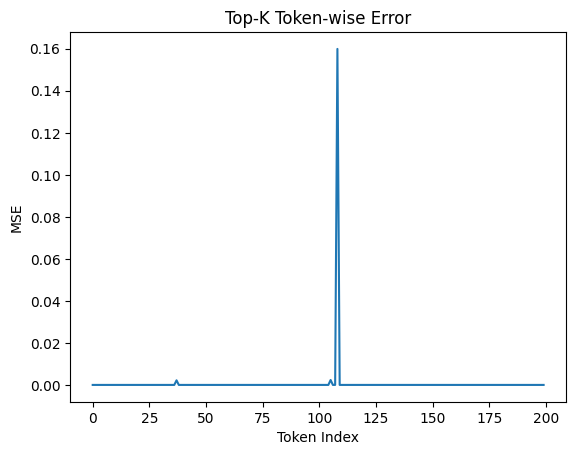

In [151]:
error_topk = torch.mean((out_full - out_topk) ** 2, dim=1)

plt.plot(error_topk.detach().numpy())
plt.title("Top-K Token-wise Error")
plt.xlabel("Token Index")
plt.ylabel("MSE")
plt.show()

In [152]:
def compute_entropy(weights):
    return -torch.sum(weights * torch.log(weights + 1e-9), dim=-1)

entropy_vals = compute_entropy(weights_full)

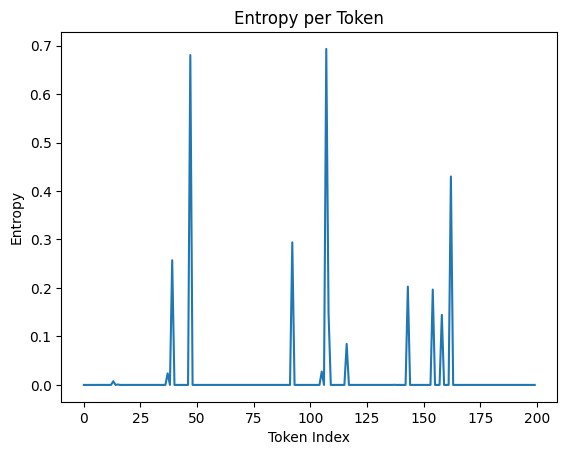

In [153]:
plt.plot(entropy_vals.detach().numpy())
plt.title("Entropy per Token")
plt.xlabel("Token Index")
plt.ylabel("Entropy")
plt.show()

In [141]:
# class HAECacheManager:
#     def __init__(self, k_budget=40, bin_size=10):
#         self.k_budget = k_budget
#         self.bin_size = bin_size
#         self.active_cache = []
#         self.recycle_bin = []

#     def push(self, k, v, attn_score, entropy, Q):
#         self.active_cache.append((k, v, attn_score, entropy))

#         if len(self.active_cache) > self.k_budget:
#             alpha = 0.5
#             self.active_cache.sort(key=lambda x: x[2] - alpha * x[3])
#             evicted = self.active_cache.pop(0)
#             self.recycle_bin.append(evicted)

#         if len(self.recycle_bin) >= self.bin_size:
#             self.summarize_bin(Q)

#     def summarize_bin(self, Q):
#         keys = torch.stack([x[0] for x in self.recycle_bin])   # (m, d)
#         vals = torch.stack([x[1] for x in self.recycle_bin])   # (m, d)

#         # Step 1: bin contribution
#         scores = Q @ keys.T
#         weights = F.softmax(scores, dim=-1)
#         output_bin = weights @ vals

#         # Step 2: OLS solve
#         Q_pinv = torch.linalg.pinv(Q)
#         W = Q_pinv @ output_bin

#         # Step 3: SVD rank-1 approx
#         U, S, Vh = torch.linalg.svd(W)
#         S = torch.clamp(S, min=1e-6)

#         k_c = U[:, 0] * torch.sqrt(S[0])
#         v_c = Vh[0, :] * torch.sqrt(S[0])

#         self.active_cache.append((k_c, v_c, 1.0, 0.0))
#         self.recycle_bin = []
#         target_size = self.k_budget - (self.bin_size - 1)  # rank-1 case
#         # while len(self.active_cache) > target_size:
#         #      self.active_cache.sort(key=lambda x: x[2] - 0.5 * x[3])
#         #      self.active_cache.pop(0)

#     def get_kv(self):
#         K = torch.stack([x[0] for x in self.active_cache])
#         V = torch.stack([x[1] for x in self.active_cache])
#         return K, V

class HAECacheManager:
    def __init__(self, k_budget=40, bin_size=10, k_rank=1):
        self.k_budget = k_budget
        self.bin_size = bin_size
        self.k_rank = k_rank
        self.active_cache = []
        self.recycle_bin = []

    def push(self, k, v, attn_score, entropy, Q):
        self.active_cache.append((k, v, attn_score, entropy))

        if len(self.active_cache) > self.k_budget:
            alpha = 0.5
            self.active_cache.sort(key=lambda x: x[2] - alpha * x[3])
            evicted = self.active_cache.pop(0)
            self.recycle_bin.append(evicted)

        if len(self.recycle_bin) >= self.bin_size:
            self.summarize_bin(Q)

    def summarize_bin(self, Q):
        keys = torch.stack([x[0] for x in self.recycle_bin])
        vals = torch.stack([x[1] for x in self.recycle_bin])

        scores = Q @ keys.T
        weights = F.softmax(scores, dim=-1)
        output_bin = weights @ vals

        Q_pinv = torch.linalg.pinv(Q)
        W = Q_pinv @ output_bin

        U, S, Vh = torch.linalg.svd(W)
        S = torch.clamp(S, min=1e-6)

        # 🔥 rank-k compression
        for i in range(self.k_rank):
            k_c = U[:, i] * torch.sqrt(S[i])
            v_c = Vh[i, :] * torch.sqrt(S[i])
            self.active_cache.append((k_c, v_c, 0.5, 0.5))

        self.recycle_bin = []

        # 🔥 enforce FAIR effective budget
        target_size = self.k_budget - (self.bin_size - self.k_rank)

        while len(self.active_cache) > target_size:
            self.active_cache.sort(key=lambda x: x[2] - 0.5 * x[3])
            self.active_cache.pop(0)

    def get_kv(self):
        K = torch.stack([x[0] for x in self.active_cache])
        V = torch.stack([x[1] for x in self.active_cache])
        return K, V

In [154]:
manager = manager = HAECacheManager(
    k_budget=k_budget,
    bin_size=bin_size,
    k_rank=k_rank
)

importance = weights_full.sum(dim=0)

for i in range(seq_len):
    manager.push(
        K[i],
        V[i],
        importance[i].item(),
        entropy_vals[i].item(),
        Q
    )

K_hae, V_hae = manager.get_kv()
out_hae, _ = attention(Q, K_hae, V_hae)

In [155]:
print("Top-K:", compute_metrics(out_full, out_topk))
print("HAE (Entropy + Bin):", compute_metrics(out_full, out_hae))

Top-K: (0.0008222635369747877, 0.9999943971633911)
HAE (Entropy + Bin): (2.2293670177459717, 0.9851340055465698)


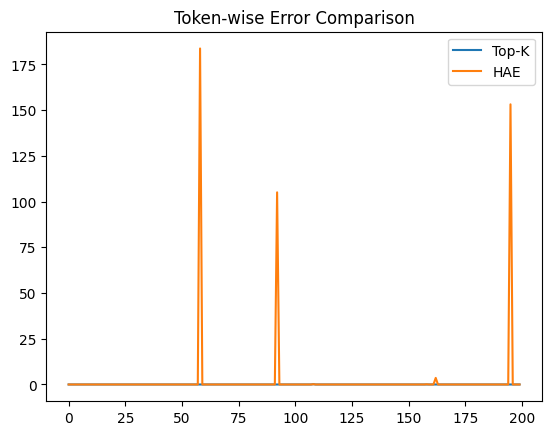

In [156]:
error_hae = torch.mean((out_full - out_hae) ** 2, dim=1)

plt.plot(error_topk.detach().numpy(), label="Top-K")
plt.plot(error_hae.detach().numpy(), label="HAE")
plt.legend()
plt.title("Token-wise Error Comparison")
plt.show()


Ratio 0.3
Top-K size: 53
HAE size: 60

Ratio 0.5
Top-K size: 93
HAE size: 98

Ratio 0.7
Top-K size: 133
HAE size: 140


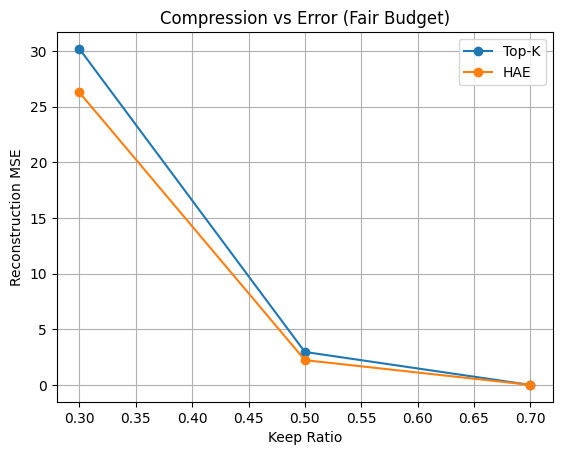

In [158]:
ratios = [0.3, 0.5, 0.7]
topk_errors = []
hae_errors = []

bin_size = 10
k_rank = 3

for r in ratios:
    k_budget = int(seq_len * r)

    # 🔥 compute fair budget
    effective_budget = k_budget - (bin_size - k_rank)

    # -------- Top-K (FAIR) --------
    K_t, V_t = attention_topk_compaction(
        K, V, weights_full, effective_budget
    )
    out_t, _ = attention(Q, K_t, V_t)
    mse_t, _ = compute_metrics(out_full, out_t)

    # -------- HAE --------
    manager = HAECacheManager(
        k_budget=k_budget,
        bin_size=bin_size,
        k_rank=k_rank
    )

    for i in range(seq_len):
        manager.push(
            K[i], V[i],
            importance[i].item(),
            entropy_vals[i].item(),
            Q[:i+1]   # 🔥 FIX: causal Q
        )

    K_h, V_h = manager.get_kv()
    out_h, _ = attention(Q, K_h, V_h)
    mse_h, _ = compute_metrics(out_full, out_h)

    # -------- sanity check --------
    print(f"\nRatio {r}")
    print("Top-K size:", K_t.shape[0])
    print("HAE size:", K_h.shape[0])

    topk_errors.append(mse_t)
    hae_errors.append(mse_h)

# -------------------------
# Plot
# -------------------------
plt.plot(ratios, topk_errors, marker='o', label="Top-K")
plt.plot(ratios, hae_errors, marker='o', label="HAE")

plt.xlabel("Keep Ratio")
plt.ylabel("Reconstruction MSE")
plt.legend()
plt.title("Compression vs Error (Fair Budget)")
plt.grid(True)
plt.show()


Ratio 0.1
Top-K: 13
Sliding: 13
OLS: 3
HAE Vanilla: 38
HAE Entropy: 13

Ratio 0.2
Top-K: 33
Sliding: 33
OLS: 3
HAE Vanilla: 56
HAE Entropy: 40

Ratio 0.3
Top-K: 53
Sliding: 53
OLS: 3
HAE Vanilla: 74
HAE Entropy: 60

Ratio 0.4
Top-K: 73
Sliding: 73
OLS: 3
HAE Vanilla: 92
HAE Entropy: 80

Ratio 0.5
Top-K: 93
Sliding: 93
OLS: 3
HAE Vanilla: 110
HAE Entropy: 98


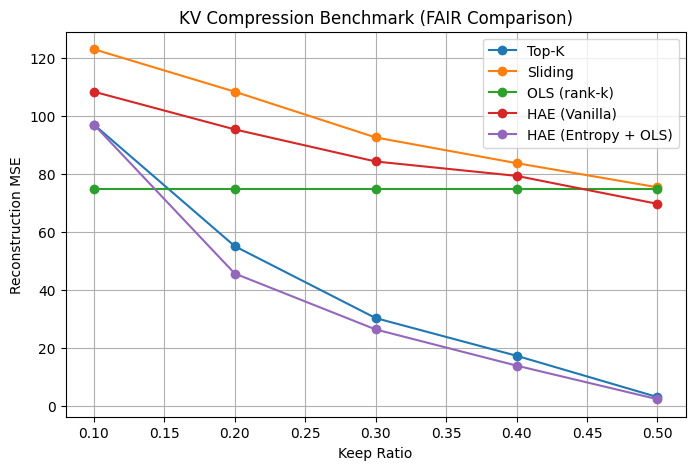

In [160]:
def run_full_benchmark_fair(Q, K, V, weights_full, entropy_vals, ratios):
    import torch
    import torch.nn.functional as F
    import matplotlib.pyplot as plt

    # -------------------------
    # Config
    # -------------------------
    bin_size = 10
    k_rank = 3

    results = {
        "Top-K": [],
        "Sliding": [],
        "OLS (rank-k)": [],
        "HAE (Vanilla)": [],
        "HAE (Entropy + OLS)": []
    }

    # -------------------------
    # Full baseline
    # -------------------------
    out_full, _ = attention(Q, K, V)
    importance = weights_full.sum(dim=0)

    # -------------------------
    # OLS compaction (rank-k)
    # -------------------------
    def ols_compaction(Q, K, V, k_rank):
        scores = Q @ K.T
        weights = F.softmax(scores, dim=-1)
        output = weights @ V

        Q_pinv = torch.linalg.pinv(Q)
        W = Q_pinv @ output

        U, S, Vh = torch.linalg.svd(W)
        S = torch.clamp(S, min=1e-6)

        K_new, V_new = [], []
        for i in range(k_rank):
            K_new.append(U[:, i] * torch.sqrt(S[i]))
            V_new.append(Vh[i, :] * torch.sqrt(S[i]))

        return torch.stack(K_new), torch.stack(V_new)

    # -------------------------
    # Loop
    # -------------------------
    for r in ratios:
        k_size = int(len(K) * r)

        # 🔥 FAIR budget
        effective_k = k_size - (bin_size - k_rank)
        effective_k = max(effective_k, 1)

        # -------- Top-K --------
        idx = torch.argsort(importance)[-effective_k:]
        K_t, V_t = K[idx], V[idx]
        out_t, _ = attention(Q, K_t, V_t)
        mse_t, _ = compute_metrics(out_full, out_t)
        results["Top-K"].append(mse_t)

        # -------- Sliding --------
        K_s, V_s = K[-effective_k:], V[-effective_k:]
        out_s, _ = attention(Q, K_s, V_s)
        mse_s, _ = compute_metrics(out_full, out_s)
        results["Sliding"].append(mse_s)

        # -------- OLS (rank-k) --------
        K_o, V_o = ols_compaction(Q, K, V, k_rank)
        out_o, _ = attention(Q, K_o, V_o)
        mse_o, _ = compute_metrics(out_full, out_o)
        results["OLS (rank-k)"].append(mse_o)

        # -------- HAE Vanilla --------
        hae_v = HAEVanilla(k_budget=k_size, bin_size=bin_size)

        for i in range(len(K)):
            hae_v.push(K[i], V[i])

        K_v, V_v = hae_v.get_kv()
        out_v, _ = attention(Q, K_v, V_v)
        mse_v, _ = compute_metrics(out_full, out_v)
        results["HAE (Vanilla)"].append(mse_v)

        # -------- HAE (Entropy + OLS) --------
        hae_e = HAECacheManager(
            k_budget=k_size,
            bin_size=bin_size,
            k_rank=k_rank
        )

        for i in range(len(K)):
            hae_e.push(
                K[i],
                V[i],
                importance[i].item(),
                entropy_vals[i].item(),
                Q[:i+1]   # 🔥 causal
            )

        K_e, V_e = hae_e.get_kv()
        out_e, _ = attention(Q, K_e, V_e)
        mse_e, _ = compute_metrics(out_full, out_e)
        results["HAE (Entropy + OLS)"].append(mse_e)

        # -------- sanity check --------
        print(f"\nRatio {r}")
        print("Top-K:", K_t.shape[0])
        print("Sliding:", K_s.shape[0])
        print("OLS:", K_o.shape[0])
        print("HAE Vanilla:", K_v.shape[0])
        print("HAE Entropy:", K_e.shape[0])

    # -------------------------
    # Plot
    # -------------------------
    plt.figure(figsize=(8,5))

    for method, values in results.items():
        plt.plot(ratios, values, marker='o', label=method)

    plt.xlabel("Keep Ratio")
    plt.ylabel("Reconstruction MSE")
    plt.title("KV Compression Benchmark (FAIR Comparison)")
    plt.legend()
    plt.grid(True)
    plt.show()

    return results
ratios = [0.1, 0.2, 0.3, 0.4, 0.5]
results = run_full_benchmark_fair(Q, K, V, weights_full, entropy_vals, ratios)

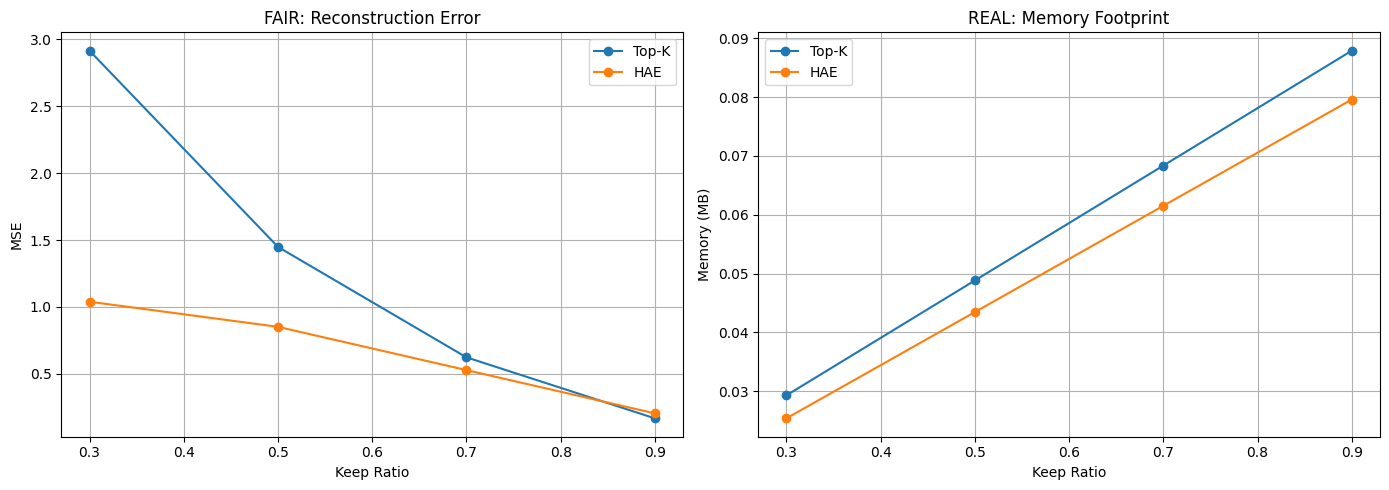


===== FAIR (MSE) =====
Ratio 0.3: Top-K=2.9155, HAE=1.0387
Ratio 0.5: Top-K=1.4485, HAE=0.8510
Ratio 0.7: Top-K=0.6232, HAE=0.5276
Ratio 0.9: Top-K=0.1669, HAE=0.2041

===== REAL (Memory MB) =====
Ratio 0.3: Top-K=0.0293, HAE=0.0254
Ratio 0.5: Top-K=0.0488, HAE=0.0435
Ratio 0.7: Top-K=0.0684, HAE=0.0615
Ratio 0.9: Top-K=0.0879, HAE=0.0796


In [171]:
def compare_fair_vs_real():
    torch.manual_seed(42)

    seq_len = 200
    d_model = 64
    ratios = [0.3, 0.5, 0.7, 0.9]

    # -------------------------
    # Config
    # -------------------------
    bin_size = 20
    k_rank = 3

    # -------------------------
    # Generate data
    # -------------------------
    X = torch.randn(seq_len, d_model)

    W = torch.randn(d_model, d_model)
    Wv = torch.randn(d_model, d_model)

    Q = X @ W
    K = X @ W
    V = X @ Wv

    Q = F.normalize(Q, dim=1)
    K = F.normalize(K, dim=1)

    # -------------------------
    # Attention
    # -------------------------
    def attention(Q, K, V):
        scores = Q @ K.T
        weights = F.softmax(scores, dim=-1)
        return weights @ V, weights

    out_full, weights_full = attention(Q, K, V)

    entropy_vals = -torch.sum(
        weights_full * torch.log(weights_full + 1e-9), dim=-1
    )
    importance = weights_full.sum(dim=0)

    # -------------------------
    # Memory function
    # -------------------------
    def kv_memory(K, V):
        return (K.numel() + V.numel()) * 4 / (1024 * 1024)

    # -------------------------
    # Storage
    # -------------------------
    mse_topk_fair, mse_hae_fair = [], []
    mem_topk_real, mem_hae_real = [], []

    # -------------------------
    # Loop
    # -------------------------
    for r in ratios:
        k_budget = int(seq_len * r)

        # =====================
        # 1. FAIR COMPARISON
        # =====================
        effective_budget = k_budget - (bin_size - k_rank)
        effective_budget = max(effective_budget, 1)

        # Top-K (fair)
        idx = torch.argsort(importance)[-effective_budget:]
        K_t_f, V_t_f = K[idx], V[idx]
        out_t_f, _ = attention(Q, K_t_f, V_t_f)
        mse_topk_fair.append(torch.mean((out_full - out_t_f)**2).item())

        # HAE (fair)
        manager_f = HAECacheManager(
            k_budget=k_budget,
            bin_size=bin_size,
            k_rank=k_rank
        )

        for i in range(seq_len):
            manager_f.push(
                K[i], V[i],
                importance[i].item(),
                entropy_vals[i].item(),
                Q[:i+1]
            )

        K_h_f, V_h_f = manager_f.get_kv()
        out_h_f, _ = attention(Q, K_h_f, V_h_f)
        mse_hae_fair.append(torch.mean((out_full - out_h_f)**2).item())

        # =====================
        # 2. REAL MEMORY
        # =====================

        # Top-K (real)
        idx = torch.argsort(importance)[-k_budget:]
        K_t_r, V_t_r = K[idx], V[idx]
        mem_topk_real.append(kv_memory(K_t_r, V_t_r))

        # HAE (real)
        manager_r = HAECacheManager(
            k_budget=k_budget,
            bin_size=bin_size,
            k_rank=k_rank
        )

        for i in range(seq_len):
            manager_r.push(
                K[i], V[i],
                importance[i].item(),
                entropy_vals[i].item(),
                Q[:i+1]
            )

        K_h_r, V_h_r = manager_r.get_kv()
        mem_hae_real.append(kv_memory(K_h_r, V_h_r))

    # -------------------------
    # Plot (SIDE BY SIDE)
    # -------------------------
    fig, axes = plt.subplots(1, 2, figsize=(14,5))

    # -------- LEFT: FAIR --------
    axes[0].plot(ratios, mse_topk_fair, marker='o', label='Top-K')
    axes[0].plot(ratios, mse_hae_fair, marker='o', label='HAE')

    axes[0].set_title("FAIR: Reconstruction Error")
    axes[0].set_xlabel("Keep Ratio")
    axes[0].set_ylabel("MSE")
    axes[0].legend()
    axes[0].grid(True)

    # -------- RIGHT: REAL --------
    axes[1].plot(ratios, mem_topk_real, marker='o', label='Top-K')
    axes[1].plot(ratios, mem_hae_real, marker='o', label='HAE')

    axes[1].set_title("REAL: Memory Footprint")
    axes[1].set_xlabel("Keep Ratio")
    axes[1].set_ylabel("Memory (MB)")
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

    # -------------------------
    # Print Summary
    # -------------------------
    print("\n===== FAIR (MSE) =====")
    for i, r in enumerate(ratios):
        print(f"Ratio {r}: Top-K={mse_topk_fair[i]:.4f}, HAE={mse_hae_fair[i]:.4f}")

    print("\n===== REAL (Memory MB) =====")
    for i, r in enumerate(ratios):
        print(f"Ratio {r}: Top-K={mem_topk_real[i]:.4f}, HAE={mem_hae_real[i]:.4f}")
compare_fair_vs_real()

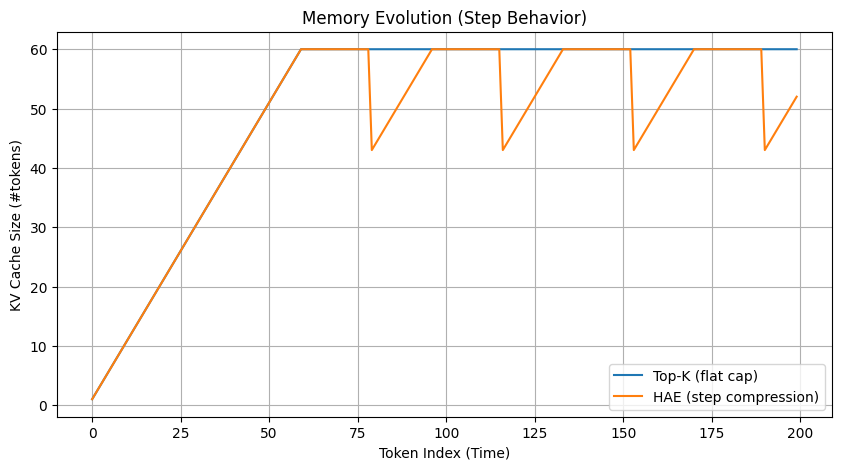

In [176]:
def plot_memory_steps():
    "HAE works like: push → grow → grow → bin full → COMPRESS "

    torch.manual_seed(42)

    seq_len = 200
    d_model = 64

    bin_size = 20
    k_rank = 3
    k_budget = 60  # fixed budget

    # -------------------------
    # Data
    # -------------------------
    X = torch.randn(seq_len, d_model)

    W = torch.randn(d_model, d_model)
    Wv = torch.randn(d_model, d_model)

    Q = F.normalize(X @ W, dim=1)
    K = F.normalize(X @ W, dim=1)
    V = X @ Wv

    scores = Q @ K.T
    weights = F.softmax(scores, dim=-1)

    entropy_vals = -torch.sum(
        weights * torch.log(weights + 1e-9), dim=-1
    )
    importance = weights.sum(dim=0)

    # -------------------------
    # Top-K tracker
    # -------------------------
    topk_curve = []

    # -------------------------
    # HAE tracker
    # -------------------------
    manager = HAECacheManager(
        k_budget=k_budget,
        bin_size=bin_size,
        k_rank=k_rank
    )

    hae_curve = []

    # -------------------------
    # Loop
    # -------------------------
    for i in range(seq_len):

        # Top-K (grows until cap)
        current_k = min(i+1, k_budget)
        topk_curve.append(current_k)

        # HAE
        manager.push(
            K[i],
            V[i],
            importance[i].item(),
            entropy_vals[i].item(),
            Q[:i+1]
        )

        hae_curve.append(len(manager.active_cache))

    # -------------------------
    # Plot
    # -------------------------
    plt.figure(figsize=(10,5))

    plt.plot(topk_curve, label="Top-K (flat cap)")
    plt.plot(hae_curve, label="HAE (step compression)")

    plt.xlabel("Token Index (Time)")
    plt.ylabel("KV Cache Size (#tokens)")
    plt.title("Memory Evolution (Step Behavior)")

    plt.legend()
    plt.grid(True)
    plt.show()
plot_memory_steps()